# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [2]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['salary_in_usd','salary'])
y = df['salary_in_usd']
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.2, random_state=1)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=1)




# -- YOUR CODE HERE --

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [3]:
X.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_currency', 'employee_residence', 'remote_ratio',
       'company_location', 'company_size'],
      dtype='object')

In [4]:
X.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3755 entries, 0 to 3754
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           3755 non-null   int64 
 1   experience_level    3755 non-null   object
 2   employment_type     3755 non-null   object
 3   job_title           3755 non-null   object
 4   salary_currency     3755 non-null   object
 5   employee_residence  3755 non-null   object
 6   remote_ratio        3755 non-null   int64 
 7   company_location    3755 non-null   object
 8   company_size        3755 non-null   object
dtypes: int64(2), object(7)
memory usage: 264.2+ KB


In [5]:
models=pd.DataFrame(columns=['model','mape','rmse','time learning','time_predict','best params'])

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import numpy as np
categorical_features = ['experience_level', 'employment_type', 'job_title',
       'salary_currency', 'employee_residence', 'company_location', 'company_size']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_features_train = encoder.fit_transform(X_train[categorical_features])
encoded_features_test = encoder.transform(X_test[categorical_features])
encoded_features_val = encoder.transform(X_val[categorical_features])

encoded_df_train = pd.DataFrame(encoded_features_train, columns=encoder.get_feature_names_out(categorical_features))
encoded_df_test = pd.DataFrame(encoded_features_test, columns=encoder.get_feature_names_out(categorical_features))
encoded_df_val = pd.DataFrame(encoded_features_val, columns=encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.concat([encoded_df_train, X_train.drop(columns=categorical_features).reset_index(drop=True)], axis=1)
X_test_encoded = pd.concat([encoded_df_test, X_test.drop(columns=categorical_features).reset_index(drop=True)], axis=1)
X_val_encoded = pd.concat([encoded_df_val, X_val.drop(columns=categorical_features).reset_index(drop=True)], axis=1)

model = LinearRegression()
model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
models.loc[len(models)]=['linear',mape,rmse,' ',' ',' ']
print('MAPE: ', mape)
print('RMSE: ', rmse)


MAPE:  0.4267430048811076
RMSE:  47199.16961002968


## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [7]:
!pip install xgboost

In [8]:
from xgboost.sklearn import XGBRegressor
from sklearn.model_selection import GridSearchCV
import time

params = {
    'max_depth': [2, 4, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 250],
    'gamma': [0, 0.1, 0.3],
    'subsample': [0.2, 0.4, 0.6],
    'min_child_weight': [1, 4]
}
xgb = XGBRegressor(random_state=1)
gsearch = GridSearchCV(
    estimator=xgb,
    param_grid=params,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=0
)
gsearch.fit(X_val_encoded, y_val)
best_params = gsearch.best_params_

start_time = time.time()
best_xgb_model = XGBRegressor(**best_params, random_state=1)
best_xgb_model.fit(X_train_encoded, y_train)
training_time = time.time() - start_time
start_time = time.time()
y_pred = best_xgb_model.predict(X_test_encoded)
prediction_time = time.time() - start_time
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
models.loc[len(models)]=['xgb',mape,rmse,training_time,prediction_time,best_params]
print('MAPE: ', mape)
print('RMSE: ', rmse)
print(f'обучение: {round(training_time, 2)} секунд')
print(f'предсказание: {round(prediction_time, 2)} секунд')
# -- YOUR CODE HERE --

MAPE:  0.4016726016998291
RMSE:  46762.679136251376
обучение: 0.88 секунд
предсказание: 0.06 секунд


## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [9]:
!pip install catboost

In [10]:
from catboost import CatBoostRegressor

params = {
    'depth': [2, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300],
    'bagging_temperature': [0, 1, 2],
    'l2_leaf_reg': [1, 3, 6]
}

cat = CatBoostRegressor(random_state=42, verbose=0, loss_function='RMSE')
gsearch = GridSearchCV(
    estimator=cat,
    param_grid=params,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=0
)
gsearch.fit(X_val_encoded, y_val)
best_params = gsearch.best_params_

start_time = time.time()
best_cat_model = CatBoostRegressor(**best_params, random_state=1, verbose=0)
best_cat_model.fit(X_train_encoded, y_train)
training_time = time.time() - start_time
start_time = time.time()
y_pred = best_cat_model.predict(X_test_encoded)
prediction_time = time.time() - start_time
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
models.loc[len(models)]=['catboost',mape,rmse,training_time,prediction_time,best_params]
print('MAPE: ', mape )
print('RMSE: ', rmse )
print(f'обучение: {round(training_time, 2)} секунд')
print(f'предсказание: {round(prediction_time, 2)} секунд')
# -- YOUR CODE HERE --

MAPE:  0.37900871988720236
RMSE:  46978.60233807279
обучение: 0.2 секунд
предсказание: 0.0 секунд


Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [11]:
from catboost import Pool
from itertools import product
cat_features = [1, 2, 3, 4, 5, 7,8]
train_pool = Pool(data=X_train, label=y_train, cat_features=cat_features)
val_pool = Pool(data=X_val, label=y_val, cat_features=cat_features)
test_pool = Pool(data=X_test, label=y_test, cat_features=cat_features)
params = {
    'depth': [2, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200, 300],
    'bagging_temperature': [0, 1, 2],
    'l2_leaf_reg': [1, 3, 6]
}

best_score = float('inf')
best_params = ''

for depth, lr, it, l2, bt in product(params['depth'], params['learning_rate'], params['iterations'], params['l2_leaf_reg'], params['bagging_temperature']):
    cat = CatBoostRegressor(
        depth=depth,
        learning_rate=lr,
        iterations=it,
        l2_leaf_reg = l2,
        bagging_temperature = bt,
        random_state=1,
        verbose=0,
        loss_function='RMSE'
    )
    cat.fit(train_pool, eval_set=val_pool, early_stopping_rounds=30)
    preds = cat.predict(val_pool)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if rmse < best_score:
        best_score = rmse
        best_params = {'depth': depth, 'learning_rate': lr, 'iterations': it, 'bagging_temperature': bt, 'l2_leaf_reg': l2}


start_time = time.time()
best_cat_model = CatBoostRegressor(**best_params, random_state=1, verbose=0)
best_cat_model.fit(train_pool)
training_time = time.time() - start_time
start_time = time.time()
y_pred = best_cat_model.predict(test_pool)
prediction_time = time.time() - start_time
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
models.loc[len(models)]=['catboost pool',mape,rmse,training_time,prediction_time,best_params]
print('MAPE: ', mape)
print('RMSE: ', rmse)
print(f'обучение: {round(training_time, 2)} секунд')
print(f'предсказание: {round(prediction_time, 2)} секунд')
# -- YOUR CODE HERE --

MAPE:  0.35612564081928155
RMSE:  45695.93724114835
обучение: 0.6 секунд
предсказание: 0.0 секунд


**Ответ:** # -- YOUR ANSWER HERE --

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [12]:
!pip install lightgbm

In [13]:
from lightgbm import LGBMRegressor

params = {
    'max_depth': [3, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.2, 0.4, 0.8],
    'min_child_weight': [1, 2]
}

lgb = LGBMRegressor(random_state=1)
gsearch = GridSearchCV(
    estimator=lgb,
    param_grid=params,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=0
)
gsearch.fit(X_val_encoded, y_val)
best_params = gsearch.best_params_

start_time = time.time()
best_lgb_model = LGBMRegressor(**best_params, random_state=1)
best_lgb_model.fit(X_train_encoded, y_train)
training_time = time.time() - start_time
start_time = time.time()
y_pred = best_lgb_model.predict(X_test_encoded)
prediction_time = time.time() - start_time
mape = mean_absolute_percentage_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
models.loc[len(models)]=['lgb',mape,rmse,training_time,prediction_time,best_params]
print('MAPE: ', mape)
print('RMSE: ', rmse)
print(f'Обучение: {round(training_time, 2)} секунд')
print(f'Предсказание: {round(prediction_time, 2)} секунд')
# -- YOUR CODE HERE --

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 34
[LightGBM] [Info] Number of data points in the train set: 375, number of used features: 15
[LightGBM] [Info] Start training from score 130844.570667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

In [14]:
models

,model,mape,rmse,time learning,time_predict,best params
0,linear,0.426743,47199.169610,,,
1,xgb,0.401673,46762.679136,0.881862,0.056533,"{'gamma': 0, 'learning_rate': 0.01, 'max_depth..."
2,catboost,0.379009,46978.602338,0.19845,0.004607,"{'bagging_temperature': 0, 'depth': 4, 'iterat..."
3,catboost pool,0.356126,45695.937241,0.604822,0.001125,"{'depth': 4, 'learning_rate': 0.05, 'iteration..."
4,lgb,0.422477,48520.030478,0.068578,0.00531,"{'learning_rate': 0.01, 'max_depth': 3, 'min_c..."


In [36]:
for c in models['best params']:
  print(c)

 
{'gamma': 0, 'learning_rate': 0.01, 'max_depth': 8, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.6}
{'bagging_temperature': 0, 'depth': 4, 'iterations': 100, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
{'depth': 4, 'learning_rate': 0.05, 'iterations': 200, 'bagging_temperature': 0, 'l2_leaf_reg': 3}
{'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 0.2}


**Ответ:** Видим, что самое высокое качество у модели cat boosting (когда мы не кодировали признаки, а использовали pool) -- как по rmse, так и по mape. Самый низкий результат показала light gbm по обеим метрикам. Однако, cat boosting pool очень долго обучается, дольше нее только xgboost (она, несмотря на то, что долго обучается, показывает средние результаты по обеим метрикам). Быстрее всех обучается линейная модель (что очевидно, она самая простая), второй идет light gbm. Оптимальная глубина у всех (кому нужно) несильно отличается -- 3 или 4. Количество оценщиков у xgboost и light gbm одинаковое по 200, learning_rate у всех разное -- у xgboost 0.01, у catboost 0.1,у catboost pool 0.05,у lgbm 0.01. Число итераций для catboost тоже разное -- у первого 100, у второго 200.

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [15]:
import pandas as pd
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [16]:
ratings = ratings.transpose()
# -- YOUR CODE HERE --

In [17]:
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [18]:
ratings = ratings.drop('user', axis=0)
# -- YOUR CODE HERE --

В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [19]:
# -- YOUR CODE HERE --
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
clint marsell,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [20]:
from sklearn.cluster import KMeans
k_means = KMeans(n_clusters=5, random_state=12345)
labels = k_means.fit_predict(ratings)
data_labels = pd.DataFrame({'Artist': ratings.index, 'Cluster': labels})
# -- YOUR CODE HERE --

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [21]:
data_labels['Cluster'].value_counts()

,count
Cluster,
1,951
2,24
0,13
3,11
4,1


**Ответ:** Видим очень явный дисбаланс -- слишком много исполнителей в первом кластере (больше 95%). Из-за этого кластеризация не очень полезна.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [22]:
cluster_counts = data_labels['Cluster'].value_counts()
single_clusters = cluster_counts[cluster_counts == 1].index
single_artists = data_labels[data_labels['Cluster'].isin(single_clusters)]['Artist']
for artist in single_artists:
    print(artist)

the beatles


Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [23]:
listen_counts = (ratings != 0).sum(axis=1) / ratings.shape[1]
mean = ratings.apply(lambda x: x[x != 0].mean() if x[x != 0].count() > 0 else 0, axis=1)
stats = pd.DataFrame({
    'share': listen_counts,
    'mean_share': mean
})

print(stats.sort_values(by='share', ascending=False).head(10))
# -- YOUR CODE HERE --

                        share  mean_share
the beatles            0.3342    0.054964
radiohead              0.2778    0.042661
deathcab for cutie     0.1862    0.035141
coldplay               0.1682    0.035852
modest mouse           0.1628    0.036095
sufjan stevens         0.1292    0.038460
dylan. bob             0.1262    0.039323
red hot clili peppers  0.1258    0.031752
pink fluid             0.1256    0.039085
kanye west             0.1250    0.037128


In [24]:
stats.mean()

,0
share,0.026826
mean_share,0.038372


**Ответ:** The Beatles лидируют по доле слушателей -- у них аж 33%, в то время как средняя доля слушателей 2%. Тоже самое и со средней долей прослушиваний.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [25]:
from sklearn.preprocessing import normalize
ratings1=ratings
ratings = normalize(ratings, norm='l2', axis=1)
ratings = pd.DataFrame(ratings, index=ratings1.index, columns=ratings1.columns)
# -- YOUR CODE HERE --

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [26]:
k_means = KMeans(n_clusters=5, random_state=1)
labels = k_means.fit_predict(ratings)
data_labels= pd.DataFrame({'artist': ratings.index, 'cluster': labels})
data_labels['cluster'].value_counts()

,count
cluster,
1,687
3,101
4,87
2,78
0,47


**Ответ** Очевидно да, потому что ситуация стала более сбалансированной. Поэтому эта кластеризация, скорее всего, будет полезнее предыдущей.

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [27]:
from scipy.spatial.distance import cosine


centroids = k_means.cluster_centers_

c = []
for i, artist_vector in enumerate(ratings.to_numpy()):
    similarities = []
    for centroid in centroids:
        similarity = 1 - cosine(artist_vector, centroid)
        similarities.append(similarity)
    c.append(similarities)
cos = pd.DataFrame(c, index=ratings.index, columns=[f'cluster_{i}' for i in range(5)])

for cluster in range(5):
    artists = cos[f'cluster_{cluster}'].sort_values(ascending=False).head(10)
    print(f'Cluster {cluster}:')
    print(artists)
# -- YOUR CODE HERE --

Cluster 0:
kanye west            0.452130
lil' wayne            0.423371
jay-z                 0.416994
t.i.                  0.403701
destinys child        0.393106
chris brown           0.381745
the game              0.380992
50 cent               0.376640
the pussycat dolls    0.357740
rihanna & jay-z       0.356377
Name: cluster_0, dtype: float64
Cluster 1:
radiohead              0.385313
the beatles            0.340987
sufjan stevens         0.310415
the shins              0.310234
the arcade fire        0.309630
deathcab for cutie     0.301648
the pixies             0.289661
belle and sebastian    0.289100
modest mouse           0.276039
spoon                  0.268481
Name: cluster_1, dtype: float64
Cluster 2:
a tribe called quest            0.480767
the roots featuring d'angelo    0.454842
nas                             0.453807
mos def                         0.418233
de la soul                      0.401005
gangstarr                       0.385742
little brother             

**Ответ:** Мы разбили музыкантов на 5 групп -- кластеры по сути разделяют исполнителей на похожих музыкантов. Действительно, можно заметить, что в нулевом кластере находятся в основном рэперы и rnb- исполнители, во втором -- скорее что-то из 70х-90х, в четвертом -- рок (я плохо разбираюсь в музыке и часть групп здесь не знаю, но смысл кластеров примерно такой).

## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

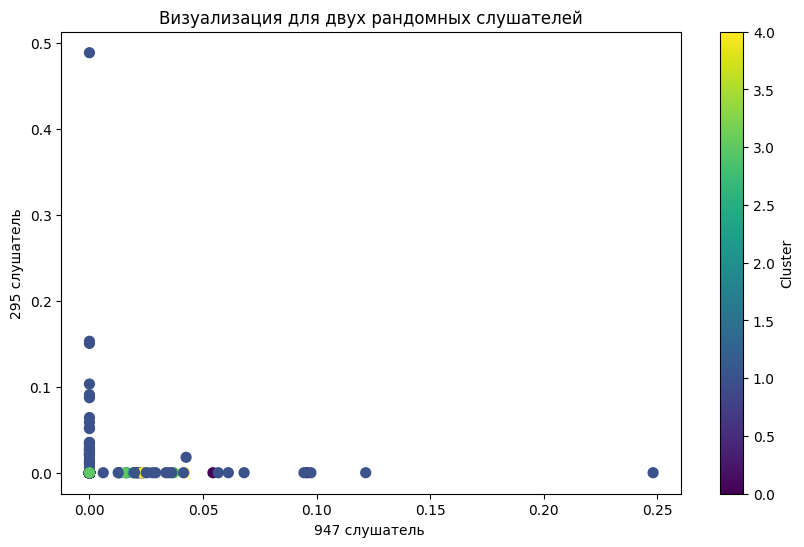

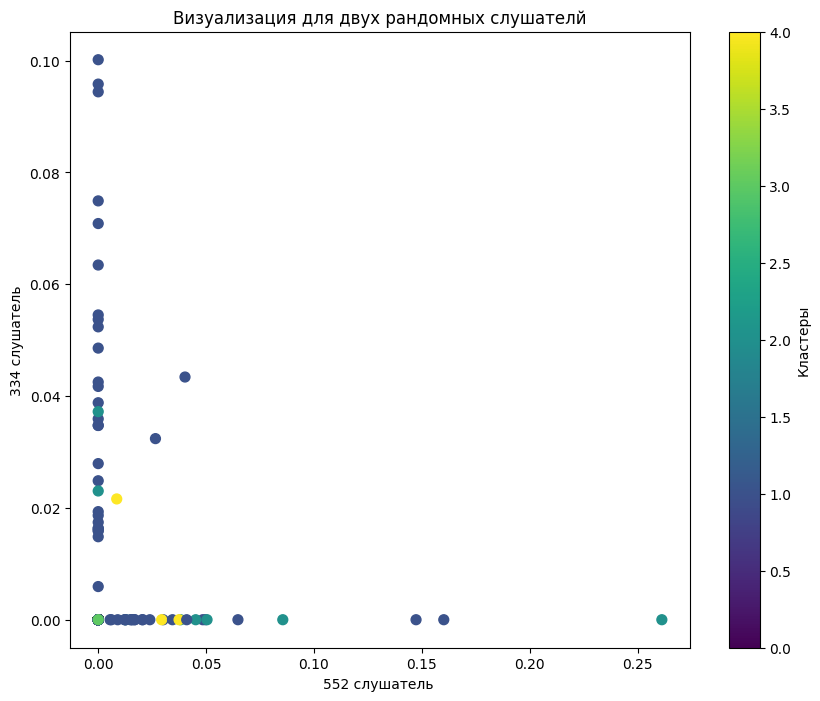

In [28]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import random
i1,i2,i3,i4=random.sample(range(1, len(ratings)), 4)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(ratings[i1], ratings[i2], c=labels, cmap='viridis', s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(str(i1)+' слушатель ')
plt.ylabel(str(i2)+' слушатель')
plt.title('Визуализация для двух рандомных слушателей')
plt.show()

plt.figure(figsize=(10, 8))
scatter = plt.scatter(ratings[i3], ratings[i4], c=labels, cmap='viridis', s=50)
plt.colorbar(scatter, label='Кластеры')
plt.xlabel(str(i3)+' слушатель ')
plt.ylabel(str(i4)+' слушатель')
plt.title('Визуализация для двух рандомных слушателй')
plt.show()
# -- YOUR CODE HERE --

**Ответ:** Понятное дело, что большую часть музыки на платформе пользователь не может послушать, поэтому есть скопление точек в левом нижнем углу. Также можно заметить, что в целом больше всего синих точек (так как нулевой кластер преобладает). Однако, мне кажется, что оба этих графика плохо показывают разбиение на кластеры (как в целом и любой такой график для рандомных двух слушателей,не очень понятно, как эти два слушатяля могут визуализировать разбиение на кластеры, если доля их прослушиваний каких-то исполнителей всегда близка к нулю).

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

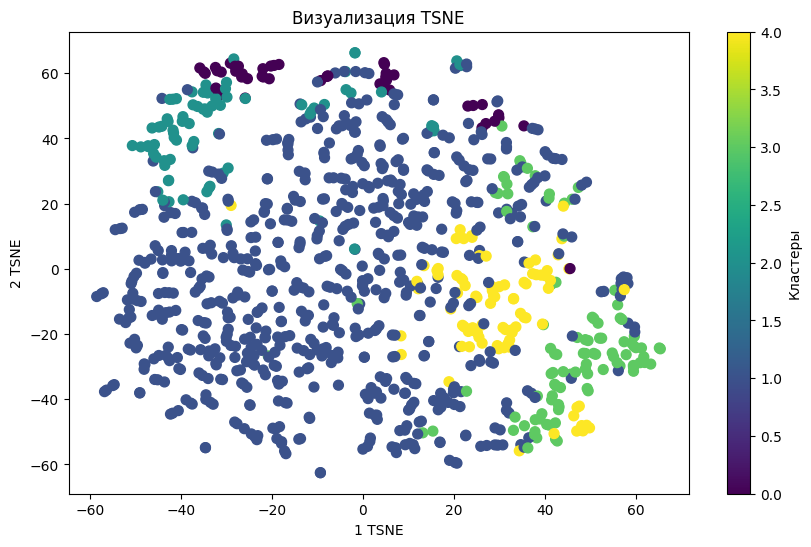

In [29]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=1234, perplexity=10)
ratings_tsne = tsne.fit_transform(ratings)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c=labels, cmap='viridis', s=50)
plt.colorbar(scatter, label='Кластеры')
plt.xlabel('1 TSNE')
plt.ylabel('2 TSNE')
plt.title('Визуализация TSNE')
plt.show()
# -- YOUR CODE HERE --

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [30]:
from sklearn.metrics import silhouette_score
import os
os.environ["OMP_NUM_THREADS"] = "4"

a= []
for k in range(2, 101):
    k_means = KMeans(n_clusters=k, random_state=42)
    labels = k_means.fit_predict(ratings)
    silhouette_avg = silhouette_score(ratings, labels)
    a.append(silhouette_avg)

best_k = a.index(max(a)) + 2
print(best_k)

# -- YOUR CODE HERE --

98


Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [31]:
k_means = KMeans(n_clusters=best_k, random_state=42)
labels = k_means.fit_predict(ratings)
data_labels= pd.DataFrame({'artist': ratings.index, 'cluster': labels})
cluster_sizes = pd.Series(labels).value_counts().sort_index()
centroids = k_means.cluster_centers_
cos = []
for i, artist_vector in enumerate(ratings.to_numpy()):
    similarities = []
    for centroid in centroids:
        similarity = 1 - cosine(artist_vector, centroid)
        similarities.append(similarity)
    cos.append(similarities)
print()
cos= pd.DataFrame(cos, index=ratings.index, columns=[f'cluster_{i}' for i in range(best_k)])


for cluster in range(best_k):
    artists = cos[f'cluster_{cluster}'].sort_values(ascending=False).head(10)
    print(f'Cluster {cluster}:')
    print(artists)# -- YOUR CODE HERE --


Cluster 0:
dr. dre                              0.548795
the faint                            0.476927
violent femmes                       0.458204
margot and the nuclear so and sos    0.457559
owen                                 0.447712
the bloodhound gang                  0.430601
cursive                              0.165210
van hallen                           0.146574
bright eyes                          0.115224
ironand wine                         0.089527
Name: cluster_0, dtype: float64
Cluster 1:
john mayer        0.529856
matt nathanson    0.504391
gavin degraw      0.437939
jason mraz        0.423514
ray lamontagne    0.407734
joshua radin      0.402298
sara bareilles    0.388338
augustana         0.380476
maroon5           0.348306
o.a.r.            0.287703
Name: cluster_1, dtype: float64
Cluster 2:
white stripes                  0.523898
beck                           0.392616
the raconteurs                 0.391461
spoon                          0.390392
the pixies  

**Ответ:** исполнители по прежнему разбились на кластеры по похожим признакам, однако в данном случае я не вижу такой явной зависимости от стиля музыки (большую часть я опять же не знаю). Думаю это связано с тем, что теперь очень много кластеров и поэтому зависимости теперь менее явные. Рассмотрим пару интересных кластеров. Кластер 15: в нем я вижу суперпопулярных рэперов (которые часто записывают вместе фиты, и в целом у них похожий стиль): канье вест, джэй зи, лил вэйн и крис браун. В кластере номер 5 находятся более нишевые исполнители: афекс твин, моби, какой-то диджей -- в целом они тоже похожи по стилю, но я не знаю как его описать, надо послушать.

Сделайте t-SNE визуализацию полученной кластеризации.

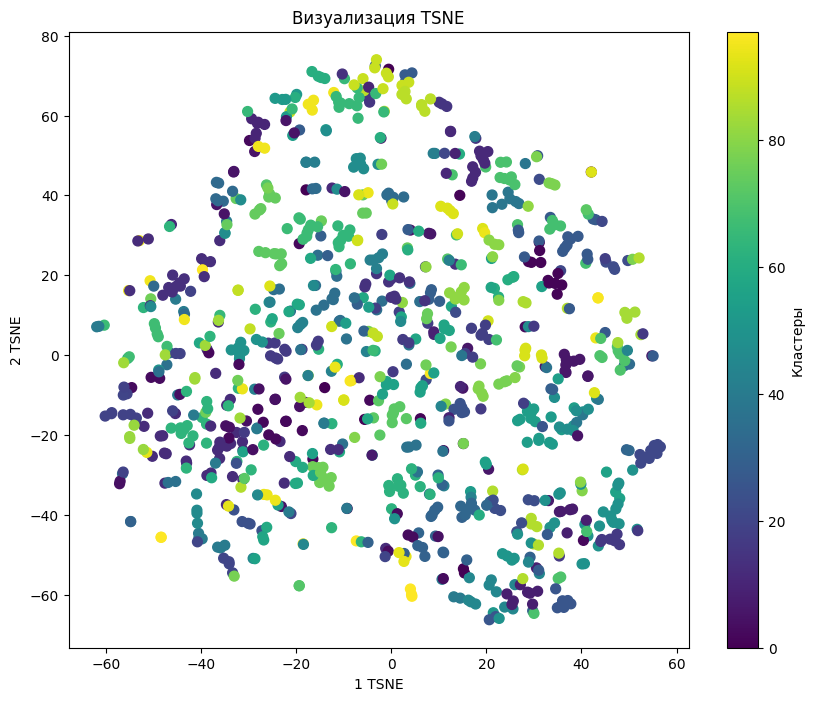

In [32]:
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
ratings_tsne = tsne.fit_transform(ratings)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c=labels, cmap='viridis', s=50)
plt.colorbar(scatter, label='Кластеры')
plt.xlabel('1 TSNE')
plt.ylabel('2 TSNE')
plt.title('Визуализация TSNE')
plt.show()# -- YOUR CODE HERE --

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

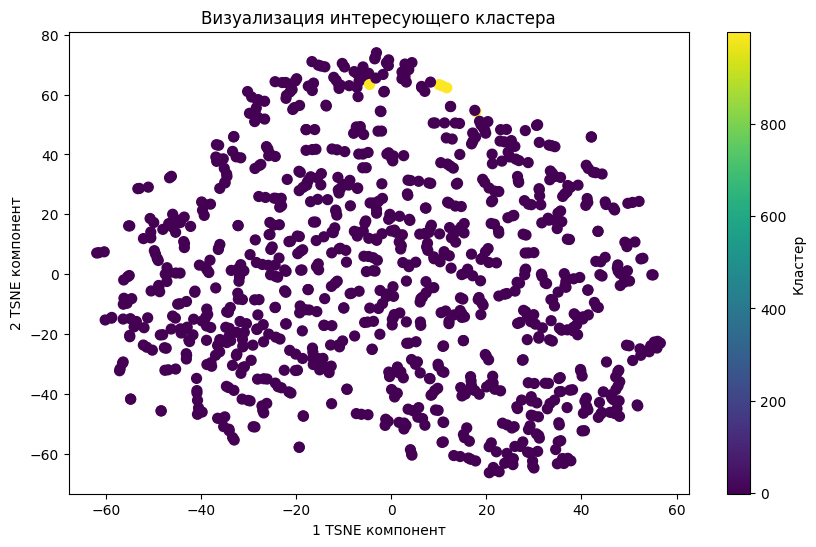

In [34]:
c = (labels == 15)
plt.figure(figsize=(10, 6))

colors = np.where(c, i, -1)

scatter = plt.scatter(ratings_tsne[:, 0], ratings_tsne[:, 1], c=colors, cmap='viridis', s=50)
plt.colorbar(scatter, label='Кластер')
plt.xlabel('1 TSNE компонент')
plt.ylabel('2 TSNE компонент')
plt.title('Визуализация интересующего кластера')
plt.show()# -- YOUR CODE HERE --

**Ответ:** Конкретно про 15ый кластер я так не думаю: по форме точки расположены примерно так же (и распределены по ней примерно равномерно), как и в предыдущей визуализации, каких-то явных скоплений точек я не вижу.